# ErgoPose Risk Classifier — Results Analysis

This notebook is the **fourth and final stage** of the *ErgoPose Risk Classifier* project.  
It evaluates and visualizes the performance of the trained ANN model, comparing predicted and actual posture classes.

### Objectives
- Load the trained model and test dataset.
- Generate predictions and compare them with ground truth labels.
- Plot confusion matrices and performance metrics.
- Analyze classification errors and discuss results.
- Provide visual and statistical interpretation of model behavior.

### Input and Output
- **Inputs:**  
  - `models/neural_network.pkl`  
  - `models/scaler.pkl`  
  - `data/processed/clean_postural_risk_dataset.csv`
- **Output:**  
  - Visualizations and performance summary tables


In [1]:
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
import json
import seaborn as sns
import matplotlib.pyplot as plt
from pathlib import Path
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

plt.style.use("seaborn-v0_8")
sns.set_palette("husl")
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print(f"✅ Bibliotecas carregadas. Usando dispositivo: {device}")

✅ Bibliotecas carregadas. Usando dispositivo: cpu


In [2]:
MODELS_PATH = Path("../models")
DATA_PATH = Path("../data/processed/clean_postural_risk_dataset.csv")

print("🔄 Coletando resultados de todos os experimentos...")

records = []
for meta_path in MODELS_PATH.rglob("metadata.json"):
    try:
        with open(meta_path, "r") as f:
            data = json.load(f)
            
        if "best_overall" in meta_path.name:
            continue
            
        metrics = data.get("metrics", {})
        
        record = {
            "Config": data.get("config_name", "unknown"),
            "Seed": data.get("seed", 0),
            "Architecture": f"{data.get('hidden_dim_1')}-{data.get('hidden_dim_2')}",
            "Learning_Rate": data.get("learning_rate"),
            "Accuracy": metrics.get("Acc", 0),
            "Precision": metrics.get("Precision", 0),
            "Recall": metrics.get("Recall", 0),
            "F1_Score": metrics.get("F1", 0)
        }
        records.append(record)
    except Exception as e:
        print(f"⚠️ Erro ao ler {meta_path}: {e}")

df_results = pd.DataFrame(records)
print(f"✅ Total de experimentos carregados: {len(df_results)}")
display(df_results.head())

🔄 Coletando resultados de todos os experimentos...
✅ Total de experimentos carregados: 100


,Config,Seed,Architecture,Learning_Rate,Accuracy,Precision,Recall,F1_Score
0,cfg_01,50,3-2,0.0100,0.853147,0.762524,0.835391,0.791359
1,cfg_08,50,8-4,0.0005,0.761579,0.658347,0.607256,0.631071
2,cfg_04,46,5-3,0.0050,0.874632,0.800002,0.838381,0.818296
3,cfg_10,42,10-5,0.0050,0.915103,0.863851,0.890310,0.876230
4,cfg_04,48,5-3,0.0050,0.880896,0.803576,0.856052,0.828238


In [3]:
if not df_results.empty:
    summary = df_results.groupby("Config").agg({
        "Accuracy": ["mean", "std"],
        "F1_Score": ["mean", "std"],
        "Precision": ["mean"],
        "Recall": ["mean"]
    }).reset_index()

    summary.columns = ['_'.join(col).strip() if col[1] else col[0] for col in summary.columns.values]

    summary = summary.sort_values(by="F1_Score_mean", ascending=False)

    print("\n🏆 Top 5 Configurações (Ordenadas por F1-Score):")
    display(summary.head(5))

    top3_configs = summary.head(3)["Config"].values
    
    subset_top3 = summary[summary["Config"].isin(top3_configs)]
    most_stable = subset_top3.loc[subset_top3["Accuracy_std"].idxmin()]

    print(f"\n💎 Configuração Mais Estável no Top 3: {most_stable['Config']}")
    print(f"   (Desvio Padrão da Acurácia: {most_stable['Accuracy_std']:.5f})")
else:
    print("⚠️ Nenhum resultado encontrado. Verifique se os notebooks anteriores rodaram corretamente.")


🏆 Top 5 Configurações (Ordenadas por F1-Score):


,Config,Accuracy_mean,Accuracy_std,F1_Score_mean,F1_Score_std,Precision_mean,Recall_mean
9,cfg_10,0.919629,0.005517,0.883609,0.007163,0.867321,0.902474
6,cfg_07,0.904422,0.007550,0.861741,0.010792,0.844665,0.883869
3,cfg_04,0.873321,0.003958,0.815094,0.007456,0.804606,0.831488
2,cfg_03,0.865394,0.013803,0.798594,0.048253,0.765748,0.840257
0,cfg_01,0.846666,0.014511,0.770516,0.047452,0.748291,0.805947



💎 Configuração Mais Estável no Top 3: cfg_04
   (Desvio Padrão da Acurácia: 0.00396)


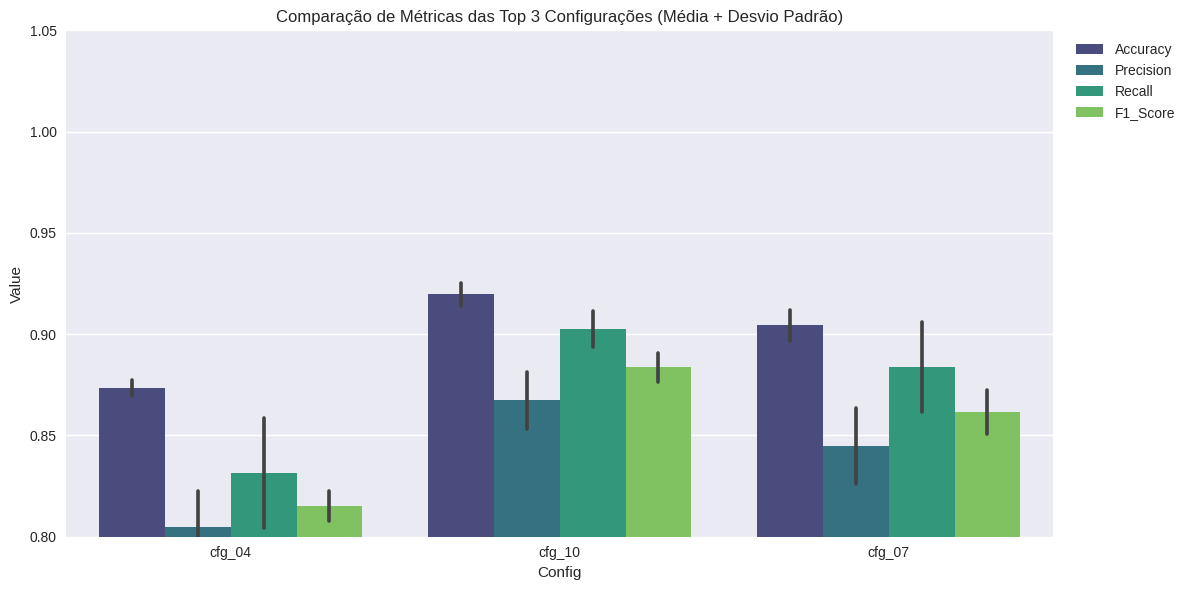

In [4]:
if not df_results.empty:
    df_top3 = df_results[df_results["Config"].isin(top3_configs)]

    df_melted = df_top3.melt(id_vars=["Config", "Seed"], 
                             value_vars=["Accuracy", "Precision", "Recall", "F1_Score"], 
                             var_name="Metric", value_name="Value")

    plt.figure(figsize=(12, 6))
    sns.barplot(data=df_melted, x="Config", y="Value", hue="Metric", errorbar="sd", palette="viridis")
    plt.title("Comparação de Métricas das Top 3 Configurações (Média + Desvio Padrão)")
    plt.ylim(0.8, 1.05) 
    plt.legend(bbox_to_anchor=(1.01, 1), loc='upper left')
    plt.tight_layout()
    plt.show()

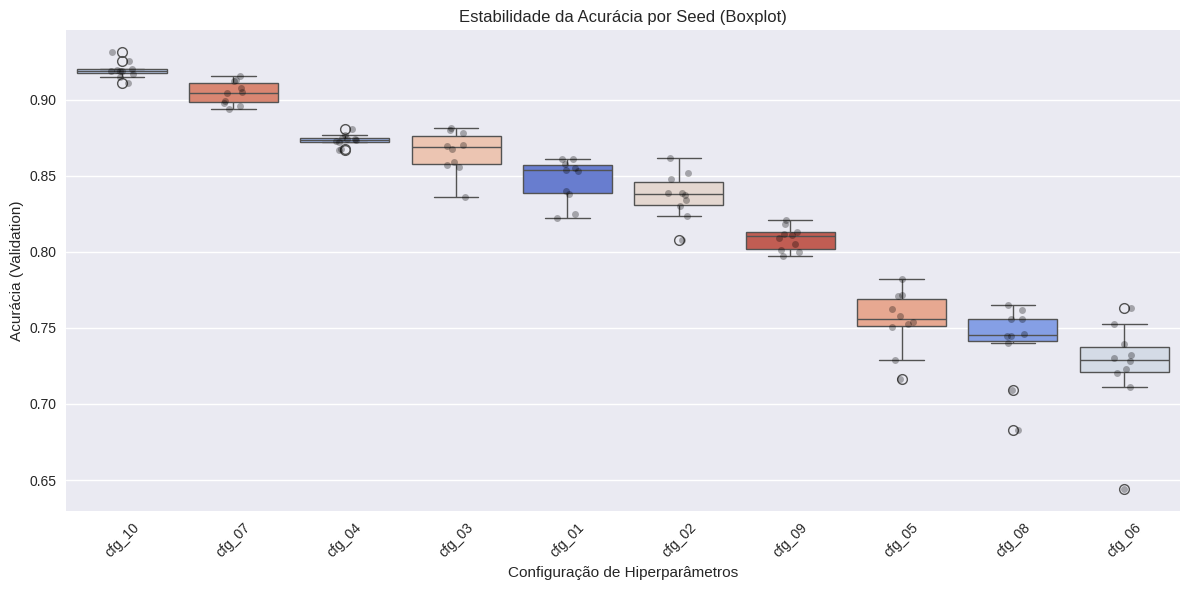

📝 Interpretação: Caixas mais 'curtas' indicam modelos mais robustos (menos variação entre execuções).


In [5]:
if not df_results.empty:
    plt.figure(figsize=(12, 6))

    sns.boxplot(data=df_results, x="Config", y="Accuracy", hue="Config", order=summary["Config"], palette="coolwarm", legend=False)
    
    sns.stripplot(data=df_results, x="Config", y="Accuracy", color='black', alpha=0.3, jitter=True, order=summary["Config"])

    plt.title("Estabilidade da Acurácia por Seed (Boxplot)")
    plt.xticks(rotation=45)
    plt.ylabel("Acurácia (Validation)")
    plt.xlabel("Configuração de Hiperparâmetros")
    plt.tight_layout()
    plt.show()

    print("📝 Interpretação: Caixas mais 'curtas' indicam modelos mais robustos (menos variação entre execuções).")

In [6]:
class MLPModel(nn.Module):
    def __init__(self, input_dim: int, hidden_dim_1: int, hidden_dim_2: int, output_dim: int):
        super(MLPModel, self).__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, hidden_dim_1),
            nn.ReLU(),
            nn.Linear(hidden_dim_1, hidden_dim_2),
            nn.ReLU(),
            nn.Linear(hidden_dim_2, output_dim),
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.net(x)
        
print("✅ Classe MLPModel definida.")

✅ Classe MLPModel definida.


In [7]:
print("Loading dataset...")
df = pd.read_csv(DATA_PATH)

X = df.drop(columns=["upperbody_label"], errors='ignore') 
y = df["upperbody_label"]

print(f"Number of features (Input Dim): {X.shape[1]}") # Deve ser 51

le = LabelEncoder()
y_encoded = le.fit_transform(y)
class_names = le.classes_
print(f"Classes: {class_names}")

X_train, X_test, y_train, y_test = train_test_split(
    X, y_encoded, test_size=0.2, random_state=42, stratify=y_encoded
)

X_test_tensor = torch.tensor(X_test.values, dtype=torch.float32).to(device)
y_test_tensor = torch.tensor(y_test, dtype=torch.long).to(device)

print(f"Conjunto de Teste pronto: {len(X_test)} amostras.")

Loading dataset...
Number of features (Input Dim): 51
Classes: ['bad' 'good']
Conjunto de Teste pronto: 959 amostras.


In [8]:
MODEL_NAME = "best_overall_model" 
MODEL_FILE = MODELS_PATH / f"{MODEL_NAME}.pth"
METADATA_FILE = MODELS_PATH / f"{MODEL_NAME}.json"

if METADATA_FILE.exists():
    with open(METADATA_FILE, "r") as f:
        meta = json.load(f)
    
    print(f"Carregando config: {meta.get('config_name', 'Unknown')}")
    
    input_dim = meta.get("input_dim", X.shape[1])
    hidden_dim_1 = meta.get("hidden_dim_1")
    hidden_dim_2 = meta.get("hidden_dim_2")
    output_dim = meta.get("output_dim", 1)
    
    print(f"Arquitetura: Entrada={input_dim} -> {hidden_dim_1} -> {hidden_dim_2} -> Saída={output_dim}")

    model = MLPModel(input_dim, hidden_dim_1, hidden_dim_2, output_dim)
    model.load_state_dict(torch.load(MODEL_FILE, map_location=device))
    model.to(device)
    model.eval()
    print("✅ Modelo carregado com sucesso!")
else:
    raise FileNotFoundError("Arquivo metadata.json não encontrado. Rode o notebook anterior.")

Carregando config: cfg_10
Arquitetura: Entrada=51 -> 10 -> 5 -> Saída=1
✅ Modelo carregado com sucesso!


In [9]:
print("Executando inferência no conjunto de teste...")

with torch.no_grad():
    logits = model(X_test_tensor).squeeze()
    
    if output_dim == 1:
        probs = torch.sigmoid(logits)
        y_pred = (probs > 0.5).long().cpu().numpy()
    else:
        probs = torch.softmax(logits, dim=1)
        y_pred = probs.argmax(dim=1).cpu().numpy()

final_acc = accuracy_score(y_test, y_pred)
print(f"🏆 Acurácia Final no Teste: {final_acc:.4f}")

Executando inferência no conjunto de teste...
🏆 Acurácia Final no Teste: 0.9416


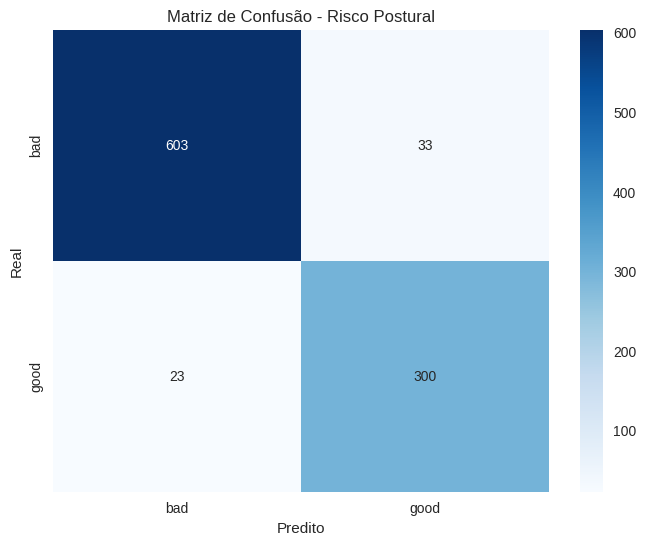


📋 Relatório de Classificação:

              precision    recall  f1-score   support

         bad       0.96      0.95      0.96       636
        good       0.90      0.93      0.91       323

    accuracy                           0.94       959
   macro avg       0.93      0.94      0.94       959
weighted avg       0.94      0.94      0.94       959



In [10]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=class_names, yticklabels=class_names)
plt.xlabel('Predito')
plt.ylabel('Real')
plt.title('Matriz de Confusão - Risco Postural')
plt.show()

print("\n📋 Relatório de Classificação:\n")
print(classification_report(y_test, y_pred, target_names=class_names))